In [10]:
import numpy as np
from helper_functions import protocol_phase_diffusion as pd
import matplotlib.pyplot as plt

In [2]:
from importlib import reload
def reload_protocols():
    reload(pd)

## cs

## Produce data

In [ ]:
sigmas = [0]

alpha_grid = np.linspace(0, np.sqrt(2), 40)
num_samples = 10000

for i, sigma in enumerate(sigmas):

    p_err_cs = pd.perr_cs(alpha_grid, sigma, num_samples)

    print(f"\rProgress: {i+1}/{len(sigmas)}", end="", flush=True)

    np.savez(f"data/phase_diff/perr_data_phase_diff_cs_a{len(alpha_grid)}_S{num_samples}_sigma{sigma}.npz", alpha_grid = alpha_grid, p_err_cs = p_err_cs, sigma = sigma)

## Load data

In [ ]:
data = np.load(f"data/phase_diff/perr_data_phase_diff_cs_a40_S3000_sigma0.1.npz")

alpha_cs = data["alpha_grid"]
p_err_cs = data["p_err_cs"]
sigma_cs = data["sigma"]

## DSS

## Produce data

In [ ]:
# Parameters
N = np.linspace(0, 2.0, 40)
beta = np.linspace(0.0, 1.0, 40)

num_samples = 10000

for sigma in [0.65, 0.75]:

    print(f"\n σ = {sigma}")
    
    # Compute error probabilities
    p_err_dss = pd.perr_dss(N, beta, sigma, num_samples)
    # Create meshgrid for plotting
    N_grid, beta_grid = np.meshgrid(N, beta, indexing="ij")
    #save data
    np.savez(f"data/phase_diff/perr_data_phase_diff_dss_N{len(N)}_b{len(beta)}_S{num_samples}_sigma{sigma}.npz", N=N, beta = beta, p_err_dss=p_err_dss, sigma = sigma)


## Load data

In [ ]:
data = np.load(f"data/perr_data_phase_diff_dss_N40_b40_S10000_sigma0.1.npz")

N_dss = data["N"]
beta_dss = data["beta"]
p_err_dss = data["p_err_dss"]
sigma_dss = data["sigma"]

## Fit

In [3]:
reload_protocols()
sigmas = np.round(np.arange(0, 1 + 0.05, 0.05), decimals=2)
params_dict_cs, params_dict_dss = pd.fit_homodyne_perr(sigmas, dss=False, cs=False, data=False, print_params=False)

In [7]:
params_dict_dss.keys()

dict_keys(['params_0.0', 'params_err_0.0', 'params_0.05', 'params_err_0.05', 'params_0.1', 'params_err_0.1', 'params_0.15', 'params_err_0.15', 'params_0.2', 'params_err_0.2', 'params_0.25', 'params_err_0.25', 'params_0.3', 'params_err_0.3', 'params_0.35', 'params_err_0.35', 'params_0.4', 'params_err_0.4', 'params_0.45', 'params_err_0.45', 'params_0.5', 'params_err_0.5', 'params_0.55', 'params_err_0.55', 'params_0.6', 'params_err_0.6', 'params_0.65', 'params_err_0.65', 'params_0.7', 'params_err_0.7', 'params_0.75', 'params_err_0.75', 'params_0.8', 'params_err_0.8', 'params_0.85', 'params_err_0.85', 'params_0.9', 'params_err_0.9', 'params_0.95', 'params_err_0.95', 'params_1.0', 'params_err_1.0'])

## Optimal Squeezing

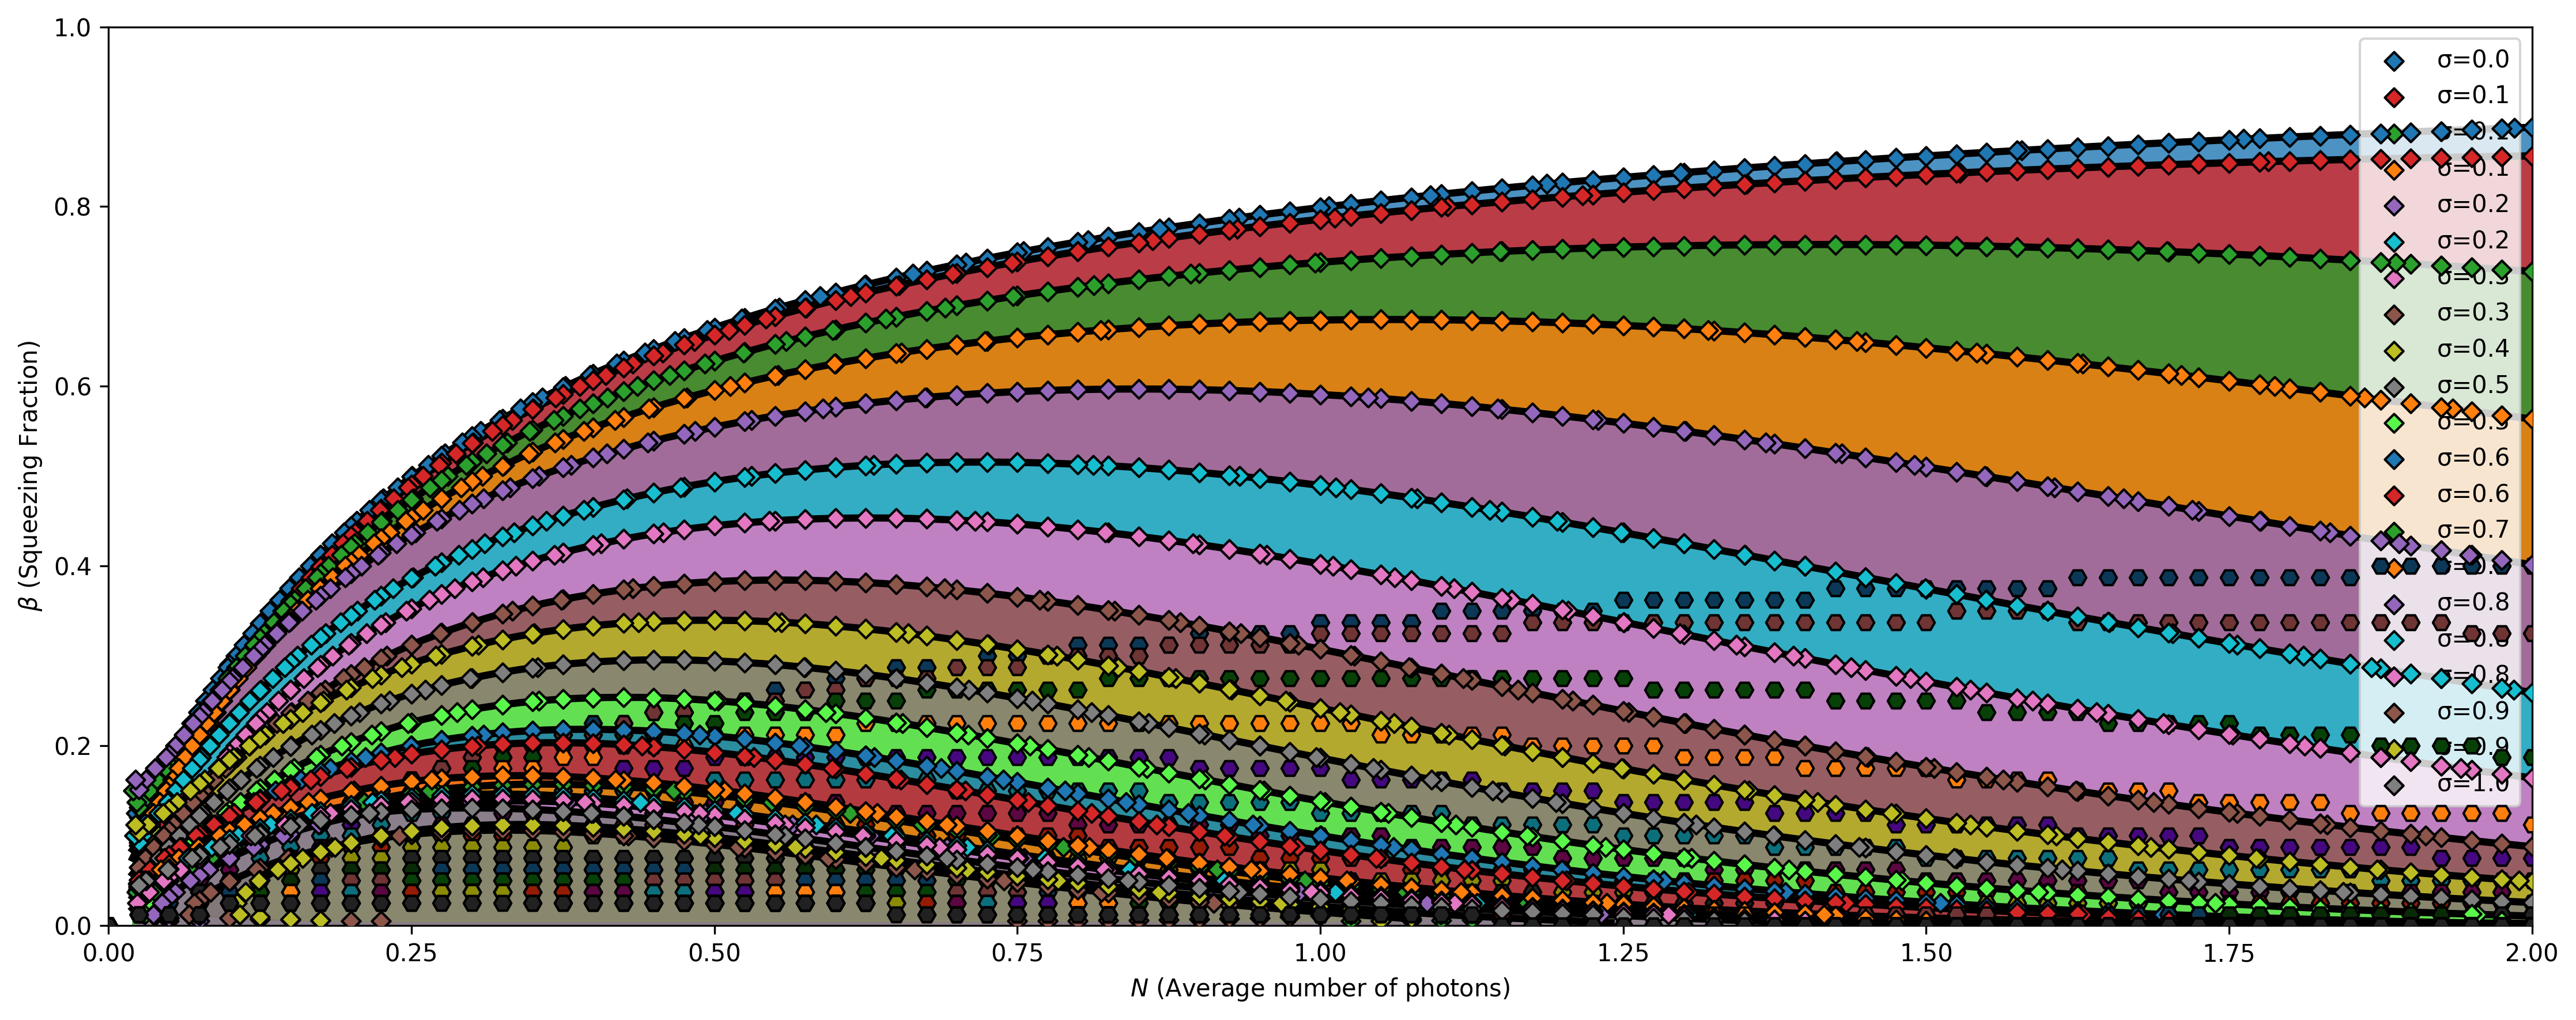

In [ ]:
reload_protocols()
beta_opt_dict = pd.optimal_squeezing(sigmas, params_dict_cs, params_dict_dss, opt = False, th = True)

In [ ]:
reload_protocols()
N_values = [1, 2, 4, 6]
pd.beta_vs_sigma(N_values, sigmas, params_dict_cs, params_dict_dss)

## Helstrom

In [48]:
reload_protocols()
p_helstrom_dss = pd.helstrom_bound(N=1, beta_opt_dict = beta_opt_dict, sigmas= sigmas, fock_cutoff=100)
p_helstrom_cs = pd.helstrom_bound(N=1, beta_opt_dict = 0, sigmas= sigmas, fock_cutoff=100)

In [49]:
reload_protocols()
p_dss_hd = pd.perr_vs_sigma(N=1, beta_opt_dict = beta_opt_dict, sigmas = sigmas, params_dict = params_dict_dss, cs=False)
p_cs_hd = pd.perr_vs_sigma(N=1, beta_opt_dict = beta_opt_dict, sigmas = sigmas, params_dict = params_dict_dss, cs=True)

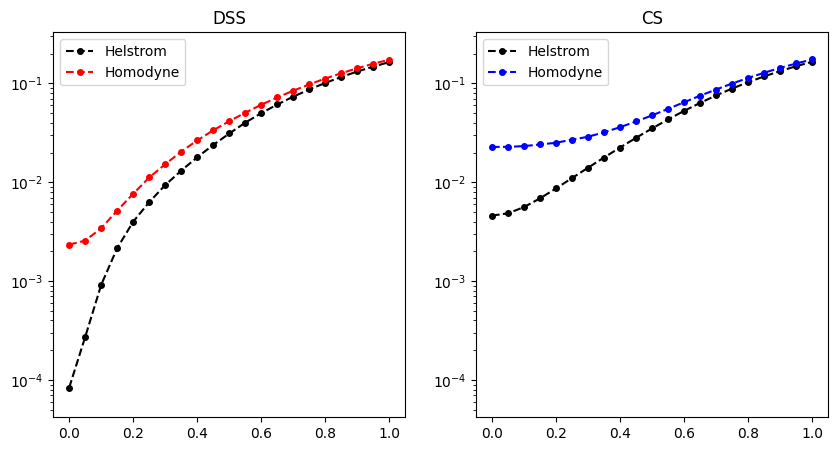

In [52]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].set_title('DSS')
ax[0].plot(sigmas, p_helstrom_dss, linestyle='--', marker='o', markersize=4, color='k', label='Helstrom')
ax[0].plot(sigmas, p_dss_hd, linestyle='--', marker='o', markersize=4, color='r', label='Homodyne')
ax[0].set_yscale('log')

ax[1].set_title('CS')
ax[1].plot(sigmas, p_helstrom_cs, linestyle='--', marker='o', markersize=4, color='k', label='Helstrom')
ax[1].plot(sigmas, p_cs_hd, linestyle='--', marker='o', markersize=4, color='b', label='Homodyne')
ax[1].set_yscale('log')

for axis in ax:
    axis.set_ylim(min(p_helstrom_dss)/2, 2*max(p_helstrom_dss))
    axis.legend()

plt.show()